In [11]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')

df = pd.read_csv(r"C:\Users\nikhi\Downloads\archive (1)\all_tickets_processed_improved_v3.csv")
df = df.dropna(subset=['Document', 'Topic_group'])
print("Total tickets:", len(df))
print("Class counts:\n", df['Topic_group'].value_counts())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total tickets: 47837
Class counts:
 Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [12]:
def clean_text(text):
    text = text.lower()                          
    text = re.sub(r'[^a-z\s]', '', text)         
    tokens = text.split()                        
    stop_words = set(stopwords.words('english'))  
    tokens = [word for word in tokens if word not in stop_words]  
    return ' '.join(tokens)

print("Cleaning text...")
df['Document_clean'] = df['Document'].apply(clean_text)


Cleaning text...


In [13]:
X = df['Document_clean']  
y = df['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=5)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000, C=5, class_weight='balanced')
model.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'



Overall Accuracy: 85.99%

Classification Report:
                       precision    recall  f1-score   support

               Access       0.89      0.90      0.90      1425
Administrative rights       0.73      0.84      0.78       352
           HR Support       0.89      0.86      0.87      2183
             Hardware       0.86      0.82      0.84      2724
     Internal Project       0.82      0.91      0.86       424
        Miscellaneous       0.81      0.86      0.83      1412
             Purchase       0.92      0.90      0.91       493
              Storage       0.87      0.92      0.89       555

             accuracy                           0.86      9568
            macro avg       0.85      0.88      0.86      9568
         weighted avg       0.86      0.86      0.86      9568



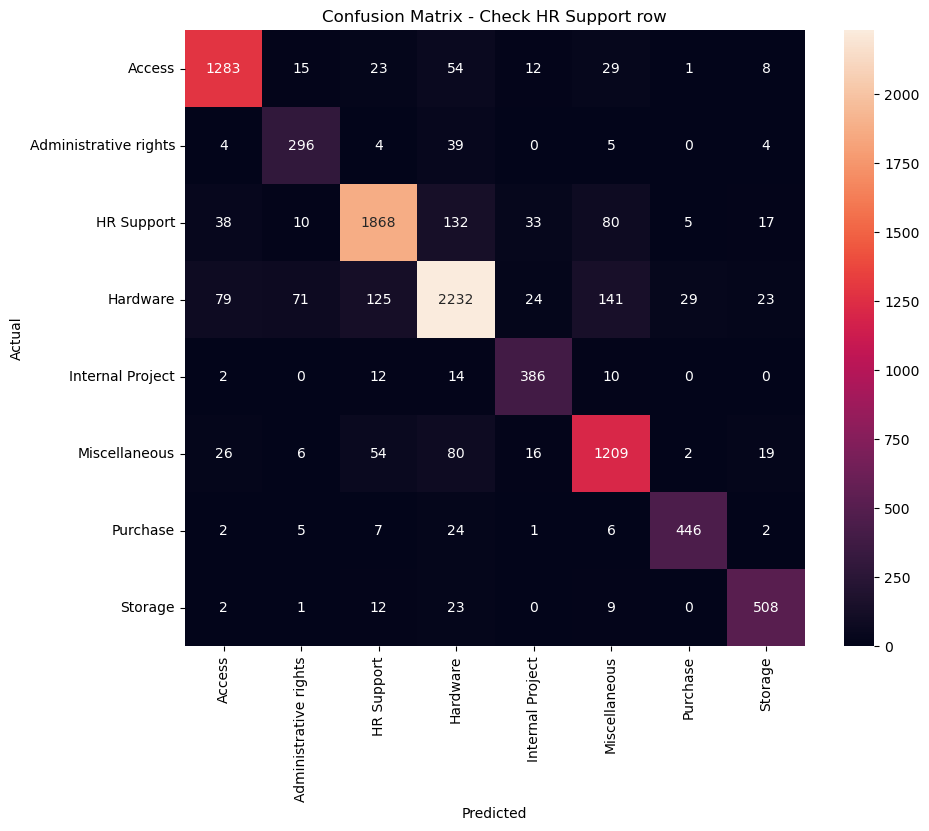

In [14]:
pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, pred) * 100

print(f"\nOverall Accuracy: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred, labels=model.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - Check HR Support row')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [15]:
def assign_priority_demo(text):
    urgent_words = {'urgent', 'asap', 'critical', 'down', 'failed', 'emergency', 'stop'}
    words = text.lower().split()  
    
    if any(word in urgent_words for word in words):
        return 'High'
    elif 'request' in words or 'please' in words:
        return 'Medium'
    else:
        return 'Low'

print("\nTesting Priority function:")
print("The system is down ->", assign_priority_demo("The system is down"))     
print("This is purgent ->", assign_priority_demo("This is purgent"))           
print("Please reset ->", assign_priority_demo("Please reset"))                 
df['Predicted_Priority_Demo'] = df['Document'].apply(assign_priority_demo)
print("\nPriority distribution:")
print(df['Predicted_Priority_Demo'].value_counts())



Testing Priority function:
The system is down -> High
This is purgent -> Low
Please reset -> Medium

Priority distribution:
Predicted_Priority_Demo
Medium    33487
Low       10515
High       3835
Name: count, dtype: int64


In [16]:
X_full_vec = tfidf.transform(df['Document_clean'])
df['Predicted_Topic_group'] = model.predict(X_full_vec)
df.to_csv('all_tickets_task2_final_submission.csv', index=False)
print("\nSaved: all_tickets_task2_final_submission.csv")
print("Columns:", df.columns.tolist())
print(df[['Document', 'Topic_group', 'Predicted_Topic_group', 'Predicted_Priority_Demo']].head())


Saved: all_tickets_task2_final_submission.csv
Columns: ['Document', 'Topic_group', 'Document_clean', 'Predicted_Priority_Demo', 'Predicted_Topic_group']
                                            Document    Topic_group  \
0  connection with icon icon dear please setup ic...       Hardware   
1  work experience user work experience user hi w...         Access   
2  requesting for meeting requesting meeting hi p...       Hardware   
3  reset passwords for external accounts re expir...         Access   
4  mail verification warning hi has got attached ...  Miscellaneous   

  Predicted_Topic_group Predicted_Priority_Demo  
0              Hardware                  Medium  
1                Access                     Low  
2              Hardware                  Medium  
3                Access                  Medium  
4         Miscellaneous                  Medium  
